# Wyjaśnienia globalne post‑hoc

## Ważność cech (permutation), PDP/ICE; wprowadzenie do DALEX


## Cel zajęć

Po zajęciach student:

* potrafi obliczyć **permutation feature importance** dla modelu ML
* potrafi narysować **Partial Dependence Plot (PDP)** i **ICE plot**
* rozumie różnicę między wyjaśnieniami globalnymi a lokalnymi
* zna podstawy użycia **DALEX** do wyjaśniania modeli

# 1. Permutation Feature Importance (ważność cech)

## Idea

Permutation importance mierzy, jak bardzo **zaburzenie jednej cechy** wpływa na jakość modelu:

1. Trenujemy model normalnie
2. Mierzymy baseline metrykę (np. ROC AUC)
3. Losowo mieszamy wartości jednej cechy
4. Sprawdzamy spadek metryki → większy spadek = ważniejsza cecha

In [8]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [9]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

In [10]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(n_estimators= 10))
])

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

In [12]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestClassifier(n_estimators=10))])

Funkcja `permutation_importance` mierzy znaczenie cech dla modelu, zadając pytanie „co się stanie, jeśli dana cecha przestanie działać lub zmienimy jej wartości?”. Najpierw oblicza metrykę jakości modelu na danych testowych (baseline), następnie losowo miesza wartości jednej cechy i ponownie mierzy metrykę – spadek jakości wskazuje, jak bardzo model zależy od tej cechy. Proces ten powtarza się kilkukrotnie dla stabilności, a następnie automatycznie dla wszystkich cech, tworząc ranking ich ważności. Duży spadek metryki oznacza cechę istotną, mały spadek cechę mniej znaczącą. Funkcja działa zarówno dla modeli liniowych, drzewiastych, jak i złożonych i pozwala zrozumieć, które cechy naprawdę napędzają predykcje modelu.


In [13]:
from sklearn.inspection import permutation_importance

# pipeline musi być już wytrenowany
result = permutation_importance(
    pipeline, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

# sortowanie wyników
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values("importance_mean", ascending=False)

importance_df

,feature,importance_mean,importance_std
7,mean concave points,0.019825,0.005830
22,worst perimeter,0.017014,0.005438
2,mean perimeter,0.008796,0.003521
20,worst radius,0.007093,0.005875
27,worst concave points,0.006779,0.003074
6,mean concavity,0.006085,0.003965
23,worst area,0.005622,0.005048
26,worst concavity,0.002331,0.001392
10,radius error,0.002331,0.000745
21,worst texture,0.001852,0.001764


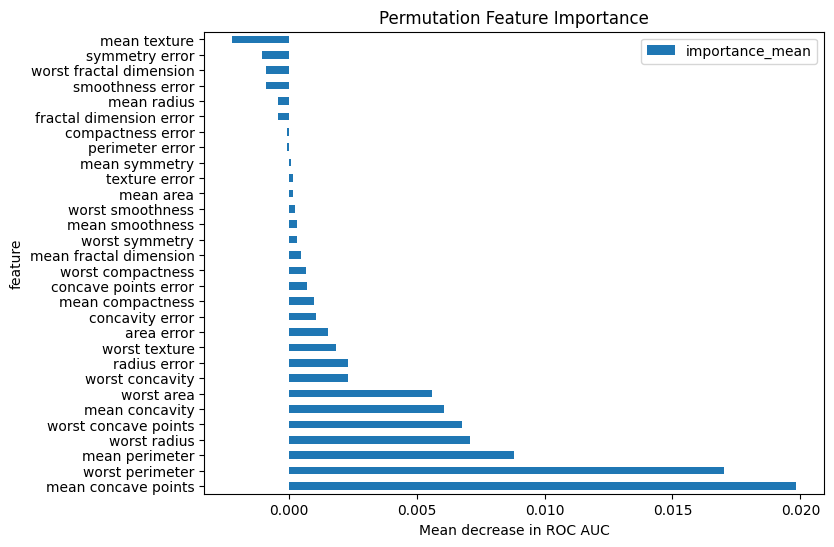

In [14]:
import matplotlib.pyplot as plt

importance_df.plot.barh(x="feature", y="importance_mean", figsize=(8,6))
plt.xlabel("Mean decrease in ROC AUC")
plt.title("Permutation Feature Importance")
plt.show()

# 2. Partial Dependence Plots (PDP) i ICE

Partial Dependence Plot (PDP) pokazuje, jak zmiana wartości jednej cechy wpływa na przewidywaną wartość modelu średnio po wszystkich obserwacjach, dając globalny obraz wpływu cechy na predykcje, natomiast Individual Conditional Expectation (ICE) rozbija ten wpływ na poszczególne obserwacje, pokazując lokalne różnice i heterogeniczność efektu. PDP ułatwia zauważenie ogólnych trendów, np. czy wzrost wartości cechy zwiększa lub zmniejsza prawdopodobieństwo klasyfikacji, a ICE pozwala zobaczyć, że niektóre przypadki mogą zachowywać się inaczej niż średnia. Obie metody służą do wyjaśniania modeli post-hoc, umożliwiają interpretację kształtu wpływu cech i są kompatybilne z dowolnym modelem uczącym się, co pomaga zrozumieć, które cechy mają największy wpływ na decyzje modelu zarówno globalnie, jak i lokalnie.

## Idea PDP

* Pokazuje, jak zmiana jednej cechy wpływa na przewidywaną wartość modelu, **średnio po wszystkich obserwacjach**
* Globalny widok wpływu cechy

## Idea ICE

* Pokazuje wpływ cechy **dla każdej obserwacji osobno**
* Lokalny widok, pokazuje heterogeniczność wpływu

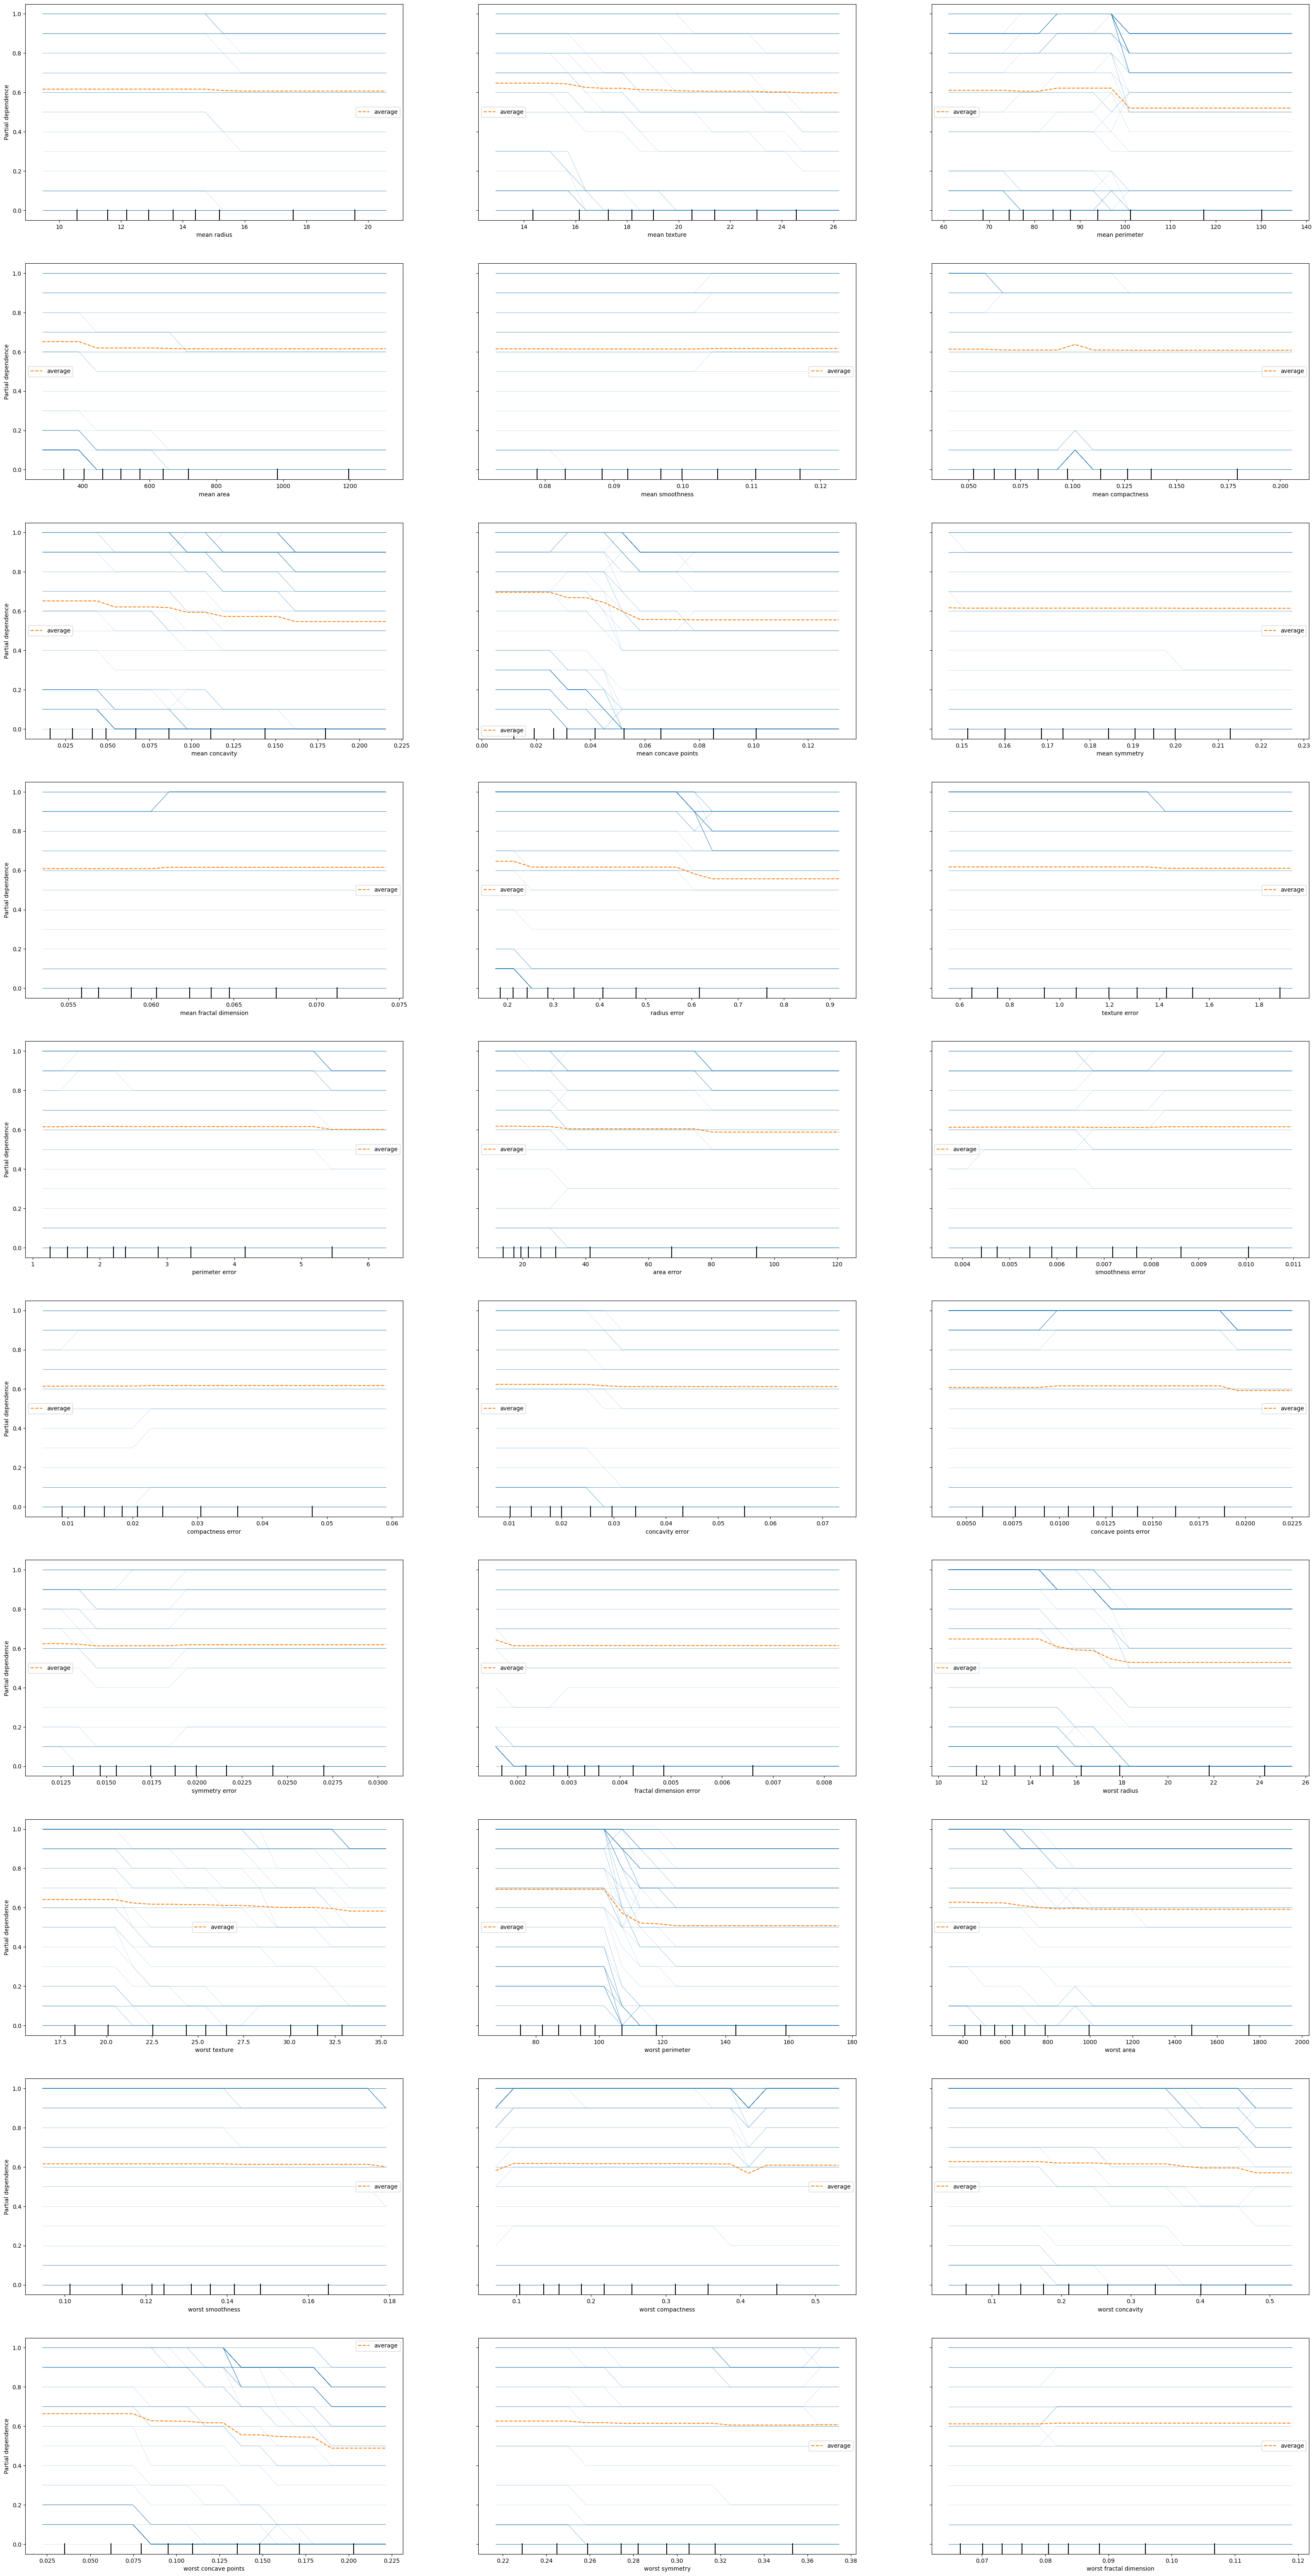

In [15]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(40, 80))

PartialDependenceDisplay.from_estimator(
    pipeline,
    X_test,
    features=X.columns.values,
    kind="both",       # PDP + ICE
    random_state=42,
    grid_resolution=20,
    ax=ax
)

plt.show()

* Linia PDP pokazuje **średnią zmianę przewidywanej wartości modelu**, gdy zmieniamy jedną cechę, trzymając pozostałe w ich naturalnych wartościach.

* **Odczyt:**

  * Oś X → wartość cechy
  * Oś Y → przewidywana wartość modelu (np. prawdopodobieństwo klasy)
  * Wzrost linii → wyższe prawdopodobieństwo klasy pozytywnej
  * Spadek linii → niższe prawdopodobieństwo

* **Interpretacja globalna:** pokazuje trend, np. „im większa wartość zmiennej, tym większe prawdopodobieństwo, że guz jest złośliwy”.

---

* Linie ICE pokazują wpływ cechy **dla każdej obserwacji osobno**.

* Można zobaczyć heterogeniczność: nie wszystkie przypadki zachowują się jak średnia (PDP).

* **Odczyt:**

  * Każda cienka linia = jedna obserwacja
  * Gruba linia = średnia PDP (opcjonalnie)
  * Rozrzut linii = zmienność wpływu cechy w populacji

* **Interpretacja lokalna:** np. dla pacjentki o nietypowych cechach zmiana zmiennej nie wpływa tak mocno jak dla większości przypadków.

#### Wskazówki do interpretacji w kontekście XAI

1. **Trend globalny (PDP)** pokazuje, które cechy mają największy wpływ i w jakim kierunku.
2. **Różnice lokalne (ICE)** pozwalają zauważyć przypadki nietypowe, które mogą wymagać dodatkowej uwagi w analizie.
3. **Punkty nieliniowe lub progi** → sygnał, że model wykorzystuje nieliniowe zależności w cechach.
4. **Szeroki rozrzut linii ICE** → cecha działa różnie w różnych regionach danych → przydatne do analizy ryzyka błędu dla konkretnych osób.

---

## A co widzimy na tym wykresie?

### Co widzimy globalnie

* **pomarańczowa linia (przerywana)** → PDP (średni wpływ cechy)
* **niebieskie linie** → ICE (pojedyncze obserwacje)

Czyli:

* pomarańczowa = „co model robi ogólnie”
* niebieskie = „co model robi dla konkretnych przypadków”

### Najważniejsza obserwacja (globalna)

W większości wykresów:

* PDP jest **dość płaskie**
* zmienia się tylko lekko (np. z ~0.55 do ~0.65)

Interpretacja:

> Większość cech **nie ma bardzo silnego globalnego wpływu** na predykcję modelu

Czyli model:

* albo korzysta z wielu cech naraz
* albo decyzja nie zależy liniowo od jednej zmiennej

To dobrze.

### ICE – bardzo ważna rzecz

Przyjrzyjmy się niebieskim liniom:

* są **poszarpane / schodkowe**
* często robią nagłe skoki

To oznacza, że:

> Model reaguje **nieliniowo i lokalnie**

### Kluczowa informacja w analizie

Jeżeli widzimy:

* PDP = płaska linia
* ICE = duże różnice

To oznacza:

> „Średnia (PDP) ukrywa to, co dzieje się lokalnie”

To wygląda bardzo charakterystycznie dla **drzewa decyzyjnego / Random Forest**.

Dlaczego?

* skoki → wynik progów (`if x < t`)
* brak gładkich krzywych → brak modelu ciągłego

### Jak interpretować konkretną cechę

Weźmy dowolny panel:

#### Jeśli PDP:

* rośnie → większa wartość cechy zwiększa prawdopodobieństwo klasy 1
* maleje → odwrotnie
* płaska → mały wpływ globalny

#### Jeśli ICE:

* linie się pokrywają → stabilny efekt
* linie się rozjeżdżają → efekt zależy od kontekstu

### Ale pamiętajmy...

#### PDP to tylko średnia

> „To, że PDP jest płaskie, NIE znaczy że cecha jest nieważna”

#### ICE pokazuje prawdę

> „Model może używać tej cechy, ale tylko dla niektórych przypadków”

#### Wysoki rozrzut ICE = interakcje

> cecha działa różnie w zależności od innych cech

### Najlepsza interpretacja tego konkretnego wykresu

Można wnioskować, że :

> Model nie opiera się silnie na pojedynczych cechach globalnie (PDP są płaskie), ale lokalnie dla konkretnych obserwacji wpływ cech może być znaczący i nieliniowy (ICE mają skoki i duży rozrzut), co sugeruje, że model wykorzystuje interakcje między cechami i decyzje oparte na progach.

Więc:

> Czy ta cecha jest ważna czy nie?

Odpowiedź brzmi:

> To zależy — globalnie nie, lokalnie tak


---
# 3. Wprowadzenie do DALEX (Python)

**DALEX** to biblioteka do wyjaśniania modeli w Pythonie i R. Ułatwia:

* tworzenie globalnych i lokalnych wyjaśnień
* wykresy ważności cech
* interpretację modeli liniowych, drzewiastych i złożonych

#### Instalacja

In [16]:
!pip install dalex


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\adria\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [18]:
import dalex as dx

# tworzymy explainer
explainer = dx.Explainer(pipeline, X_test, y_test, label="RandomForestClassifier")

# ważność cech (feature importance)
vi = explainer.model_parts()
vi.plot()

Preparation of a new explainer is initiated

  -> data              : 114 rows 30 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 114 values
  -> model_class       : sklearn.ensemble._forest.RandomForestClassifier (default)
  -> label             : RandomForestClassifier
  -> predict function  : <function yhat_proba_default at 0x000001AB88310940> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.0, mean = 0.616, max = 1.0
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.9, mean = 0.0158, max = 0.8
  -> model_info        : package sklearn

A new explainer has been created!


## Co robi ten kod?

```python
explainer = dx.Explainer(pipeline, X_test, y_test)
```

Tworzysz obiekt, który:

- „opakowuje” model + dane + sposób predykcji
- pozwala liczyć różne metody XAI (tu: permutation importance)

---

```python
vi = explainer.model_parts()
vi.plot()
```

- Liczy **feature importance (permutation)**
- Rysuje wykres ważności cech

## Co oznacza ten log (najważniejsze elementy)

### data

```text
114 rows 30 cols
```

→ masz 114 obserwacji i 30 cech


### model_class

```text
RandomForestClassifier
```

→ model, który wyjaśniasz

### predict function

```text
yhat_proba_default
```

- DALEX używa **prawdopodobieństw**, a nie klas

### predicted values

```text
predicted values  : min = 0.0, mean = 0.616, max = 1.0
```

#### Co to jest?

To są **przewidywane prawdopodobieństwa klasy pozytywnej**, czyli można to przedstawić jako:

In [22]:
pipeline.predict_proba(X_test)[:,1]

array([0. , 1. , 0.1, 0.3, 0. , 1. , 1. , 0. , 0. , 0. , 1. , 0.1, 1. ,
       0. , 0.1, 1. , 0.2, 1. , 1. , 0.7, 0. , 0.6, 1. , 1. , 1. , 0.6,
       0.1, 1. , 1. , 1. , 0.9, 1. , 1. , 1. , 0. , 0.7, 1. , 0.9, 0.9,
       0. , 1. , 1. , 0.9, 0. , 0. , 0.7, 1. , 1. , 0.7, 0. , 1. , 0.6,
       1. , 0.9, 1. , 1. , 1. , 0.1, 0. , 1. , 1. , 1. , 1. , 0.9, 0. ,
       0.5, 0.4, 1. , 1. , 0.8, 1. , 1. , 1. , 0. , 0. , 0. , 0. , 1. ,
       1. , 1. , 0.9, 1. , 0. , 1. , 0.6, 1. , 0.9, 1. , 1. , 1. , 0.7,
       1. , 0. , 0.1, 0. , 1. , 0.1, 1. , 0. , 0.9, 0. , 0. , 0. , 1. ,
       0. , 0. , 1. , 0. , 1. , 0. , 0.5, 0. , 0.8, 1. ])

#### Jak to interpretować?

##### min = 0.0

→ model jest **pewny**, że niektóre przypadki to klasa 0
(np. zdrowy)

##### max = 1.0

→ model jest **pewny**, że niektóre przypadki to klasa 1
(np. złośliwy)

##### 🔹 mean = 0.616

Jest to średnia przewidywana wartość równa wartości 0.616

To oznacza:

> model „średnio” daje ~61.6% prawdopodobieństwa klasy 1

**To NIE znaczy, że „61% danych to klasa 1”**

To znaczy, że model średnio przewiduje wyższe prawdopodobieństwo klasy 1 od klasy 0.

### Finalne wnioski

Rozkład predykcji jest szeroki → model dobrze rozróżnia klasy

To ma wpływ na interpretację:

* jeśli predykcje są blisko 0/1 → model jest „pewny”
* jeśli są ~0.5 → model jest „niepewny”

### PDP / ICE w DALEX

In [ ]:
pdp_radius = explainer.model_profile(variables="mean radius", type="partial") #PDP
pdp_radius.plot()

Calculating ceteris paribus:   0%|          | 0/1 [00:00<?, ?it/s]

Calculating ceteris paribus: 100%|██████████| 1/1 [00:00<00:00, 30.30it/s]


In [21]:
pdp_radius = explainer.model_profile(variables="mean radius", type="conditional") # ICE
pdp_radius.plot()

Calculating conditional dependency: 100%|██████████| 1/1 [00:00<00:00, 13.07it/s]


# 4. Refleksja - co do czego

* **Permutation importance** → globalna, pokazuje które cechy są naprawdę ważne
* **PDP / ICE** → pozwalają zobaczyć kształt wpływu cechy (linearny, nieliniowy, progi)
* **DALEX** → unifikuje te metody i daje gotowe wykresy

# 5. Zadania praktyczne (opcjonalne, do przećwiczenia)

1. Oblicz permutation importance dla wszystkich cech w innym zbiorze danych
2. Zrób PDP i ICE dla 2 najważniejszych cech
3. Porównaj wyniki scikit-learn z DALEX
4. Zastanów się, które cechy są **najbardziej stabilne**, a które dają **lokalnie różne efekty**
